In [1]:
# 第1章｜打造專屬 Python 實驗室：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


# 打造專屬 Python 實驗室

**對應影片**：第 1 章 單元 1「打造專屬 Python 實驗室 I」、單元 2「打造專屬 Python 實驗室 II」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 用 conda（後來改 Docker）在自己電腦架環境，需要高規格電腦 | 直接用 **Google Colab**，打開瀏覽器就能跑；想在自己電腦跑，`pip install -r requirements.txt` 即可 |
| 用 `crawler.py` 爬蟲自建幾 GB 的 pickle 資料庫 | 改用 FinLab 官方資料 API：`data.get('price:收盤價')` 一行取得整理好的資料 |

這一本只做三件事：確認環境、登入、讀到第一筆資料。

## 1. 登入說明

第一格的 `finlab.login()` 會印出一個登入網址：

1. 點網址，用 FinLab 帳號登入（沒有帳號就在頁面上免費註冊）。
2. 回到這個 notebook，看到「已登入」就完成了。

登入資訊會記在這台機器上，之後重開 notebook 不用再登入。Colab 的機器每次重新連線都是新的，所以 Colab 每次都要登入一次。

**免費會員**可以跑完整門課。免費會員的資料到 2018 年底，每天可下載 500 MB；付費會員的資料更新到最新交易日。

## 2. 確認套件版本

In [2]:
import sys
from importlib.metadata import version

PACKAGES = ['finlab', 'pandas', 'numpy', 'ta-lib', 'scikit-learn', 'lightgbm', 'tensorflow']

print('Python', sys.version.split()[0])
for package in PACKAGES:
    print(f'{package:<14}{version(package)}')

Python 3.12.13
finlab        2.0.21
pandas        2.3.3
numpy         2.5.3
ta-lib        0.8.1
scikit-learn  1.9.1
lightgbm      4.7.0
tensorflow    2.21.0


## 3. 讀取第一筆資料

`data.get('資料表:欄位')` 會回傳一張表：**列是日期、欄是股票代號**。
資料會從 FinLab 下載，第一次讀取需要幾秒鐘。

In [3]:
close = data.get('price:收盤價')
close

symbol,0015,00400A,00401A,00402A,00403A,00404A,00405A,00406A,00407A,00408A,...,9944,9945,9946,9949,9950,9951,9955,9958,9960,9962
date,,,,,,,,,,,,,,,,,,,,,
2007-04-23,9.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,31.00,30.35,9.78,73.60,13.25,51.3,72.40,NaN,46.00,49.60
2007-04-24,9.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32.00,30.50,9.91,75.00,13.25,50.5,71.60,NaN,45.90,50.40
2007-04-25,9.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32.30,29.50,10.10,74.60,13.30,49.9,71.60,NaN,49.10,49.10
2007-04-26,9.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,31.60,29.15,10.80,74.50,13.25,49.5,71.00,NaN,48.90,48.00
2007-04-27,9.55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,31.40,28.50,11.55,75.70,13.15,48.8,69.50,NaN,48.60,46.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.30,44.95,12.40,9.80,13.25,84.3,12.90,67.1,29.20,11.60
2018-12-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.30,44.40,12.30,9.51,13.30,80.9,12.80,65.0,29.65,11.50
2018-12-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.35,44.30,12.30,9.39,13.50,76.7,12.60,63.2,28.60,11.60


In [4]:
print('資料期間：', close.index[0].date(), '到', close.index[-1].date())
print('股票檔數：', close.shape[1])

資料期間： 2007-04-23 到 2018-12-28
股票檔數： 2782


取出台積電（2330）與元大台灣 50（0050）的收盤價，畫成走勢圖：

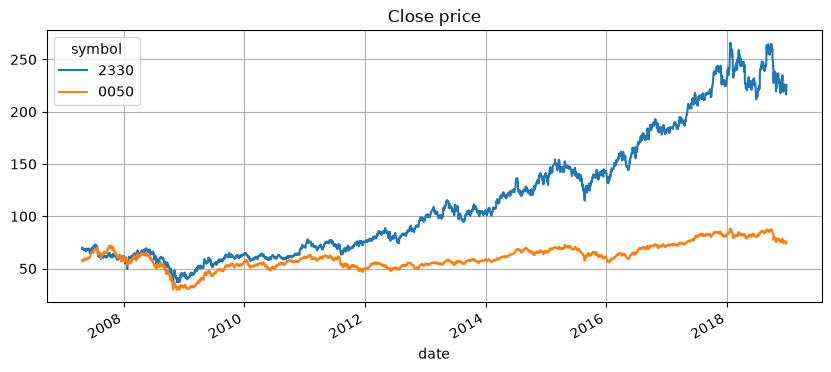

In [5]:
close[['2330', '0050']].plot(figsize=(10, 4), title='Close price', grid=True);

## 4. Colab 使用小提醒

- 左上角「執行階段 → 全部執行」可以一次跑完整本 notebook。
- 閒置太久 Colab 會中斷連線，變數會消失。重新連線後，從第一格開始重跑即可。
- 想保留自己的修改：「檔案 → 在雲端硬碟中儲存複本」。

環境準備好了，下一個單元我們自己寫一支爬蟲，抓大盤的 1 分 K。